y(0.0) = 1.000000
y(0.5) = 1.088287
y(1.0) = 2.024341
y(1.5) = 6.134981
y(2.0) = 19.330336


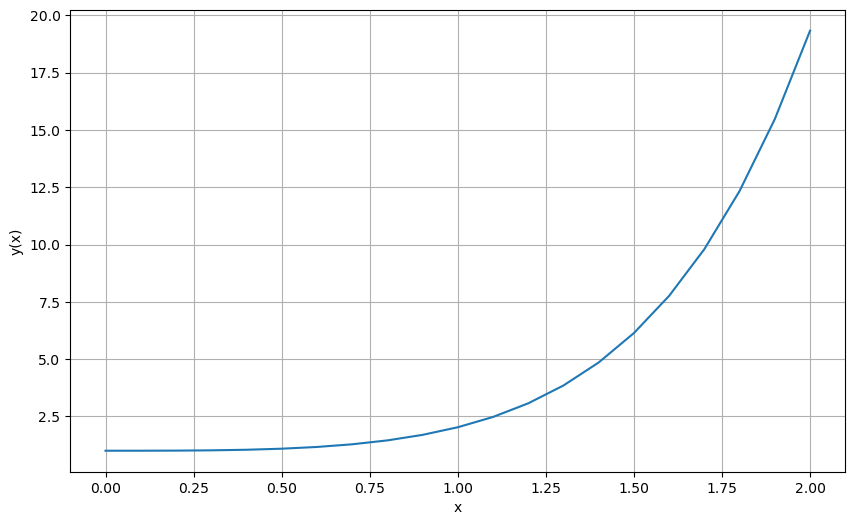

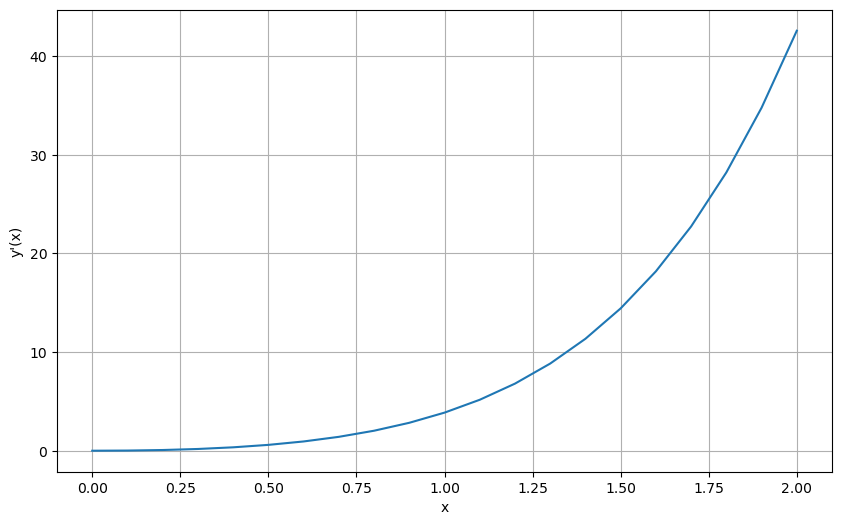

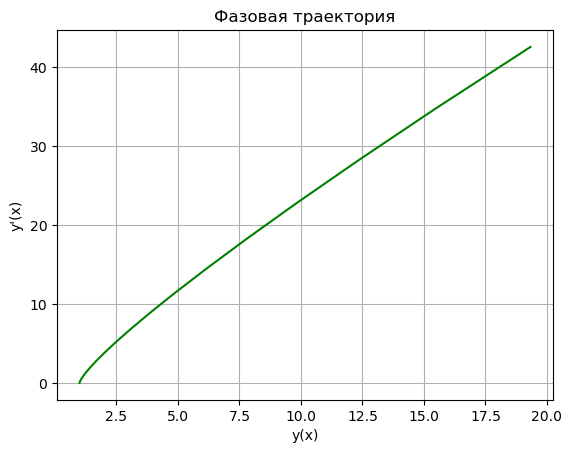

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def f(x, y):
    y1, y2, y3 = y
    dy1dx = y2
    dy2dx = y3
    dy3dx = 2*y3 - y2 + 2*y1 + np.cos(x)*np.exp(2*x)
    return np.array([dy1dx, dy2dx, dy3dx])

def merson_step(f, x, y, h, eps=0.01):
    while True:

        k1 = h * f(x, y)
        k2 = h * f(x + h/3, y + k1/3)
        k3 = h * f(x + h/3, y + k1/6 + k2/6)
        k4 = h * f(x + h/2, y + k1/8 + 3*k3/8)
        k5 = h * f(x + h, y + k1/2 - 3*k3/2 + 2*k4)
        
        y_new = y + (k1 + 4*k4 + k5)/6
        
        error = np.max(np.abs(h/5*(k1 - 4.5*k3 + 4*k4 - 0.5*k5)))
        
        if error/eps > 5:
            h *= 0.5
        else:
            return x + h, y_new, h

def solve_merson(f, y0, x0, x_end, h0=0.1, eps=0.01):

    x = [x0]
    y = [np.array(y0)]
    h = h0

    while x[-1] < x_end:
        xi, yi, h = merson_step(f, x[-1], y[-1], h, eps)
        x.append(xi)
        y.append(yi)
        
        if xi + h > x_end:
            h = x_end - xi
    
    return np.array(x), np.array(y)

y0 = [1.0, 0.0, 0.0]
x0 = 0.0
x_end = 2.0

x, y = solve_merson(f, y0, x0, x_end, h0=0.1, eps=0.01)

y_solution = y[:, 0]
dy_solution = y[:, 1]

for xi, yi in zip(x[::5], y_solution[::5]):
    print(f"y({xi:.1f}) = {yi:.6f}")
    

plt.figure(figsize=(10, 6))
plt.plot(x, y_solution)
plt.xlabel('x')
plt.ylabel('y(x)')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(x, dy_solution)
plt.xlabel('x')
plt.ylabel("y'(x)")
plt.grid(True)
plt.show()

plt.plot(y_solution, dy_solution, 'g-')
plt.xlabel('y(x)')
plt.ylabel("y'(x)")
plt.title('Фазовая траектория')
plt.grid(True)


In [30]:
#        max_rel_error = np.max(error / (np.abs(y_new) + 1e-12))
print("\nРешение с помощью solve_ivp:")
for xi, yi in zip(x_scipy[::5], y_solution_scipy[::5]):
    print(f"y({xi:.1f}) = {yi:.6f}")
    
"""""""""""
print("Решение методом Мерсона:")
for xi, yi in zip(x_merson[::3], y_solution_merson[::3]):
    print(f"y({xi:.1f}) = {yi:.6f}")
print('')
print("\nРешение с помощью solve_ivp:")
for xi, yi in zip(x_scipy[::3], y_solution_scipy[::3]):
    print(f"y({xi:.1f}) = {yi:.6f}")
""""""""""

Количество итераций 14
Средняя погрешность: 2.544554e-02
Максимальная погрешность: 9.063699e-02


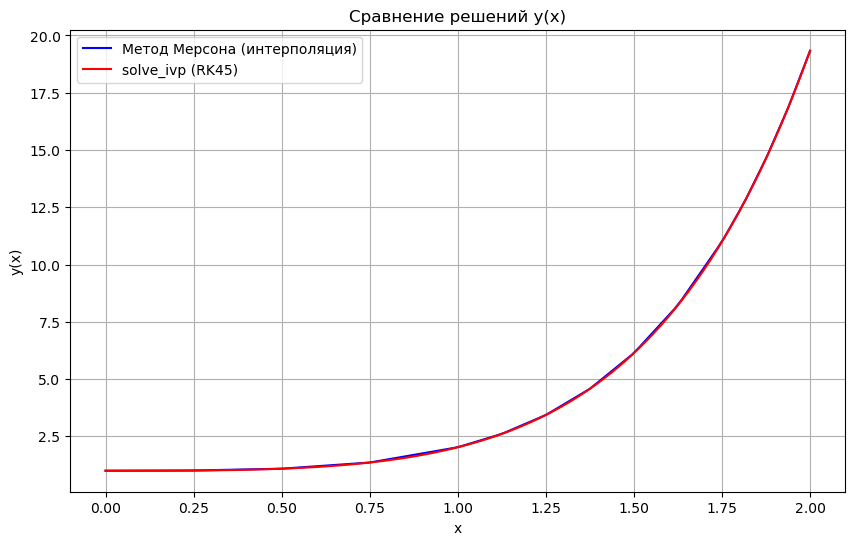

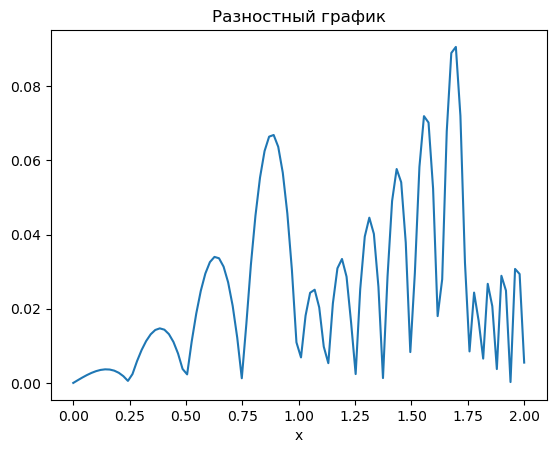

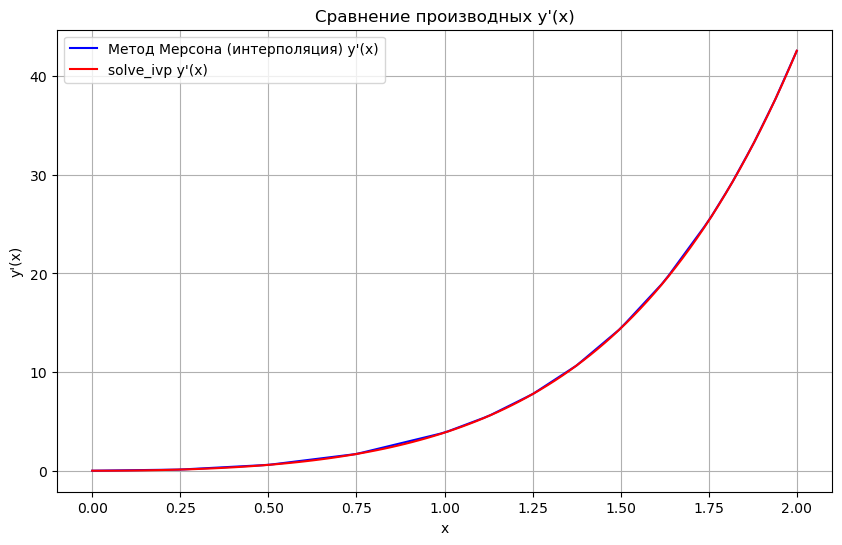

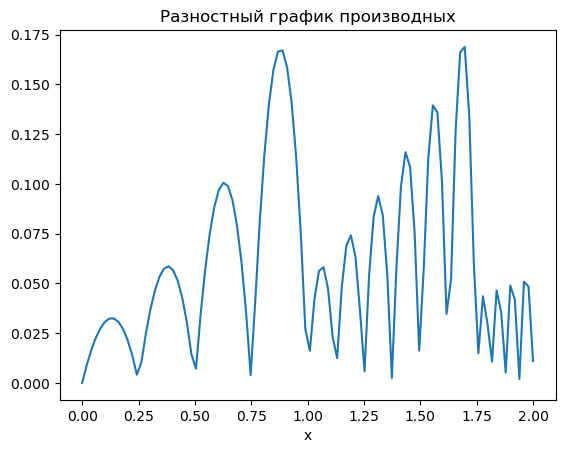

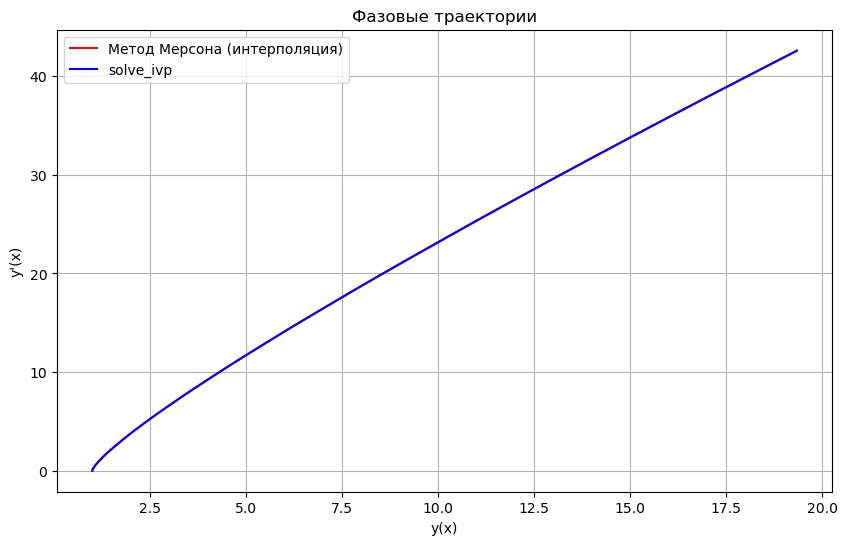

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def f(x, y):
    y1, y2, y3 = y
    dy1dx = y2
    dy2dx = y3
    dy3dx = 2*y3 - y2 + 2*y1 + np.cos(x)*np.exp(2*x)
    return np.array([dy1dx, dy2dx, dy3dx])

def merson_step(f, x, y, h, eps):
    while True:
        k1 = h * f(x, y)
        k2 = h * f(x + h/3, y + k1/3)
        k3 = h * f(x + h/3, y + k1/6 + k2/6)
        k4 = h * f(x + h/2, y + k1/8 + 3*k3/8)
        k5 = h * f(x + h, y + k1/2 - 3*k3/2 + 2*k4)
        
        y_new = y + (k1 + 4*k4 + k5)/6
        
        error = np.max(np.abs(0.2*(k1 - 4.5*k3 + 4*k4 - 0.5*k5)))
        
        if error <= eps:
            return x + h, y_new, h
        else:
            h *= 0.5
            if h < 1e-10:
                raise RuntimeError("Слишком маленький шаг интегрирования")

def solve_merson(f, y0, x0, x_end, h0, eps):
    x = [x0]
    y = [np.array(y0)]
    h = h0
    iters = 0

    while x[-1] < x_end:
        xi, yi, h = merson_step(f, x[-1], y[-1], h, eps)
        x.append(xi)
        y.append(yi)
        iters += 1
        
        if xi + h > x_end:
            h = x_end - xi
    
    return np.array(x), np.array(y), iters

y0 = [1.0, 0.0, 0.0]
x0 = 0.0
x_end = 2.0
eps = 0.001
h0 = 0.5

x_merson, y_merson, iterations = solve_merson(f, y0, x0, x_end, h0, eps)
y_solution_merson = y_merson[:, 0]
dy_solution_merson = y_merson[:, 1]

sol = solve_ivp(f, (x0, x_end), y0, method='RK45', t_eval=np.linspace(x0, x_end, 100))
x_scipy = sol.t
y_scipy = sol.y
y_solution_scipy = y_scipy[0, :]
dy_solution_scipy = y_scipy[1, :]

print("Количество итераций", iterations)

y_solution_merson_interp = np.interp(x_scipy, x_merson, y_solution_merson)
dy_solution_merson_interp = np.interp(x_scipy, x_merson, dy_solution_merson)

average_error = np.mean(abs(y_solution_merson_interp - y_solution_scipy))
print(f"Средняя погрешность: {average_error:.6e}")
max_error = np.max(abs(y_solution_merson_interp - y_solution_scipy))
print(f"Максимальная погрешность: {max_error:.6e}")

plt.figure(figsize=(10, 6))
plt.plot(x_scipy, y_solution_merson_interp, 'b-', label='Метод Мерсона (интерполяция)')
plt.plot(x_scipy, y_solution_scipy, 'r-', label='solve_ivp (RK45)')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.legend()
plt.grid(True)
plt.title('Сравнение решений y(x)')
plt.show()

plt.plot(x_scipy, abs(y_solution_merson_interp - y_solution_scipy))
plt.xlabel('x')
plt.title('Разностный график')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(x_scipy, dy_solution_merson_interp, 'b-', label="Метод Мерсона (интерполяция) y'(x)")
plt.plot(x_scipy, dy_solution_scipy, 'r-', label="solve_ivp y'(x)")
plt.xlabel('x')
plt.ylabel("y'(x)")
plt.legend()
plt.grid(True)
plt.title("Сравнение производных y'(x)")
plt.show()

plt.plot(x_scipy, abs(dy_solution_merson_interp - dy_solution_scipy))
plt.xlabel('x')
plt.title('Разностный график производных')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(y_solution_merson_interp, dy_solution_merson_interp, 'r-', label='Метод Мерсона (интерполяция)')
plt.plot(y_solution_scipy, dy_solution_scipy, 'b-', label='solve_ivp')
plt.xlabel('y(x)')
plt.ylabel("y'(x)")
plt.title('Фазовые траектории')
plt.legend()
plt.grid(True)
plt.show()


Количество итераций 22
Решение методом Мерсона:
y(0.0) = 1.000000
y(0.1) = 1.000014
y(0.2) = 1.001900
y(0.4) = 1.028237
y(0.6) = 1.127589
y(0.8) = 1.376667
y(1.0) = 1.892757
y(1.2) = 2.850862
y(1.4) = 4.506220
y(1.6) = 7.222563
y(1.8) = 11.505505
y(2.0) = 16.512258


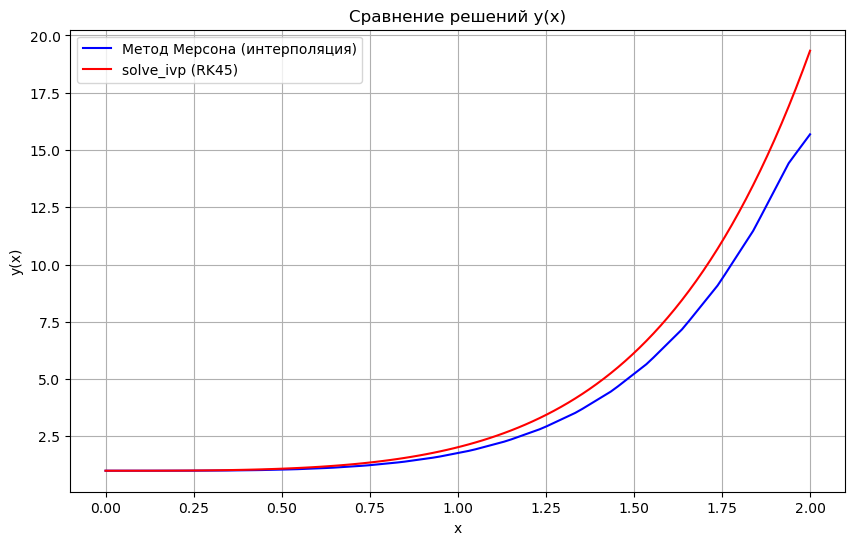

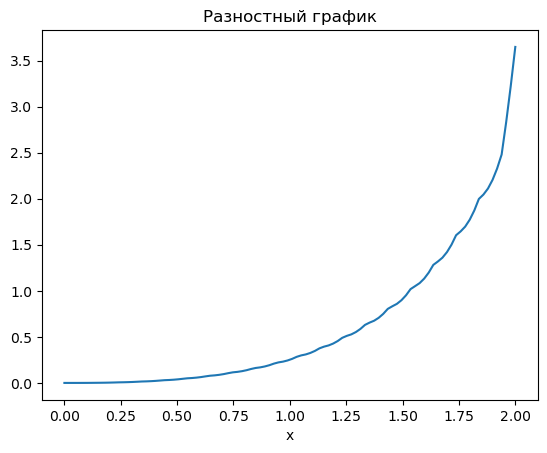

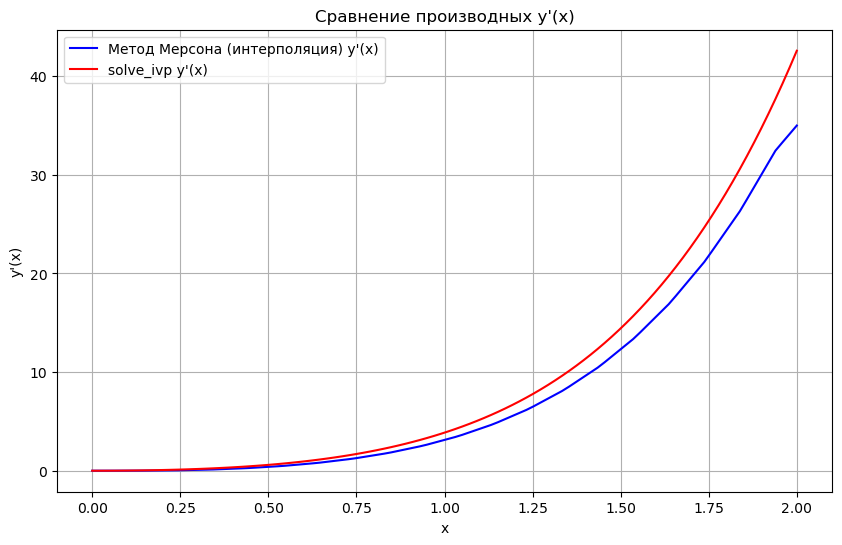

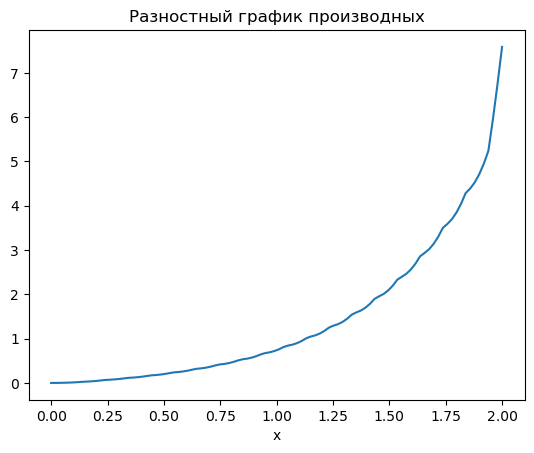

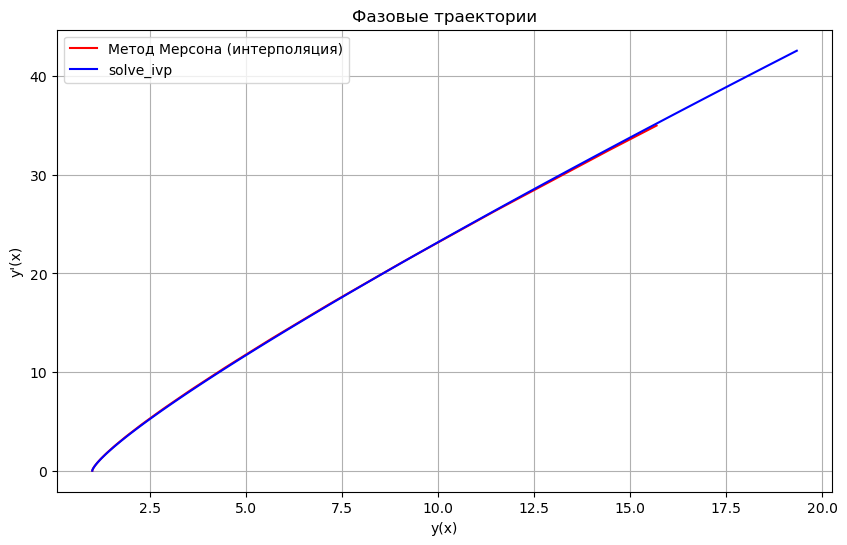

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def f(x, y):
    y1, y2, y3 = y
    dy1dx = y2
    dy2dx = y3
    dy3dx = 2*y3 - y2 + 2*y1 + np.cos(x)*np.exp(2*x)
    return np.array([dy1dx, dy2dx, dy3dx])

def merson_step(f, x, y, h, eps=0.01):
    while True:
        k1 = h * f(x, y)
        k2 = h * f(x + h/3, y + k1/3)
        k3 = h * f(x + h/3, y + k1/6 + k2/6)
        k4 = h * f(x + h/2, y + k1/8 + 3*k3/8)
        k5 = h * f(x + h, y + k1/2 - 3*k3/2 + 2*k4)
        
        y_new = y + (k1 + 4*k4 + k5)/6
        
        error = np.max(np.abs(h/5*(k1 - 4.5*k3 + 4*k4 - 0.5*k5)))
        
        if error / eps > 1:
            h *= 0.5
        elif error / eps < 0.5:
            h *= 2
            if h > 0.1:
                h = 0.1
        
        if error / eps <= 1:
            return x + h, y_new, h

def solve_merson(f, y0, x0, x_end, h0=0.01, eps=0.01):
    x = [x0]
    y = [np.array(y0)]
    h = h0
    iters = 0

    while x[-1] < x_end:
        xi, yi, h = merson_step(f, x[-1], y[-1], h, eps)
        x.append(xi)
        y.append(yi)
        iters += 1
        
        if xi + h > x_end:
            h = x_end - xi
    
    return np.array(x), np.array(y), iters

y0 = [1.0, 0.0, 0.0]
x0 = 0.0
x_end = 2.0

x_merson, y_merson, iterations = solve_merson(f, y0, x0, x_end, h0=0.01, eps=0.01)
y_solution_merson = y_merson[:, 0]
dy_solution_merson = y_merson[:, 1]

sol = solve_ivp(f, (x0, x_end), y0, method='RK45', t_eval=np.linspace(x0, x_end, 100))
x_scipy = sol.t
y_scipy = sol.y
y_solution_scipy = y_scipy[0, :]
dy_solution_scipy = y_scipy[1, :]

print("Количество итераций", iterations)

print("Решение методом Мерсона:")
for xi, yi in zip(x_merson[::2], y_solution_merson[::2]):
    print(f"y({xi:.1f}) = {yi:.6f}")

y_solution_merson_interp = np.interp(x_scipy, x_merson, y_solution_merson)
dy_solution_merson_interp = np.interp(x_scipy, x_merson, dy_solution_merson)

plt.figure(figsize=(10, 6))
plt.plot(x_scipy, y_solution_merson_interp, 'b-', label='Метод Мерсона (интерполяция)')
plt.plot(x_scipy, y_solution_scipy, 'r-', label='solve_ivp (RK45)')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.legend()
plt.grid(True)
plt.title('Сравнение решений y(x)')
plt.show()

plt.plot(x_scipy, abs(y_solution_merson_interp - y_solution_scipy))
plt.xlabel('x')
plt.title('Разностный график')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(x_scipy, dy_solution_merson_interp, 'b-', label="Метод Мерсона (интерполяция) y'(x)")
plt.plot(x_scipy, dy_solution_scipy, 'r-', label="solve_ivp y'(x)")
plt.xlabel('x')
plt.ylabel("y'(x)")
plt.legend()
plt.grid(True)
plt.title("Сравнение производных y'(x)")
plt.show()

plt.plot(x_scipy, abs(dy_solution_merson_interp - dy_solution_scipy))
plt.xlabel('x')
plt.title('Разностный график производных')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(y_solution_merson_interp, dy_solution_merson_interp, 'r-', label='Метод Мерсона (интерполяция)')

plt.plot(y_solution_scipy, dy_solution_scipy, 'b-', label='solve_ivp')
plt.xlabel('y(x)')
plt.ylabel("y'(x)")
plt.title('Фазовые траектории')
plt.legend()
plt.grid(True)
plt.show()
